# Matching Anomalies to Astronomical Intuition

In [1]:
import os

# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import joblib

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from anomaly.constants import GALAXY_LINES
from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail
from anomaly.utils import specobjid_to_idx

from anomaly.utils import get_sdss_spec_img
from astroExplain.spectra.utils import get_anomaly_score_name
from astroExplain.spectra.notebook import explain_reconstruction_score

from astroExplain.spectra.latent import explain_iforest_score
from astroExplain.spectra.latent import explain_lof_score
from astroExplain.spectra.explanation import TellMeWhy

from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Lime weights

In [3]:
def get_weights(
    wave,
    explanation,
    max_normalization=True,
) -> tuple:

    why = TellMeWhy(wave=wave, explanation=explanation)
    weights = why.get_heatmap()

    if max_normalization is True:
        weights = np.abs(weights) / np.nanmax(np.abs(weights))

    return weights

## Plot 5X2 explanations

In [4]:
def plot_same_anomaly_explanations(
    data: dict,
    wave_nm: np.ndarray,
    line_configs: dict,
    spec_ylim,
    spec_yticks,
    xai_config: dict = {"y_lim": (0, 1.35), "y_ticks": [0, 0.5, 1]},
    text_dict={"x": 0.01, "y": 0.9, "ha": "left", "va": "center"},
    bbox_to_anchor=(0.695, 0.52, 0.5, 0.5),
    figsize=(14, 8.75),
):

    spectrum = data["spectrum"]
    image = img_common_dict[anomaly_name]

    fig, axs = plt.subplots(5, 2, sharex=True, figsize=figsize)

    # Map the scores to their respective rows and columns
    scores_layout = [
        ("SE", "RSE"),  # Row 1
        ("Filter SE", "Filter RSE"),  # Row 2
        ("Trim SE", "Trim RSE"),  # Row 3
        ("Filter + Trim SE", "Filter + Trim RSE"),  # Row 4
    ]

    # =================================================================================
    # Plot Row 0: Original Spectrum (Both Columns)
    # =================================================================================
    for c in [0, 1]:

        axs[0, c], _ = spec_photo_thumbnail(
            axs[0, c],
            wave_nm,
            spectrum,
            image,
            add_image=True,
            bbox_to_anchor=bbox_to_anchor,
        )
        axs[0, c].set_ylim(spec_ylim)
        axs[0, c].set_yticks(spec_yticks)
        axs[0, c].minorticks_on()

        if c == 0:
            axs[0, c].set_ylabel("Flux")
        else:
            axs[0, c].tick_params(labelleft=False)

        if line_configs.get("spectrum", {}).get("active_lines"):
            add_line_indicators(
                axs[0, c], wave_nm, spectrum, **line_configs["spectrum"]
            )

    # ================================================================================
    # Rows 1-4: Explanations
    # ================================================================================
    for i, (score_se, score_rse) in enumerate(scores_layout):
        # Offset by 1 because Row 0 is the spectrum
        r = i + 1
        # Iterate through Col 0 (SE) and Col 1 (RSE)
        for c, score_name in enumerate([score_se, score_rse]):

            axs[r, c], _ = spec_photo_thumbnail(
                axs[r, c], wave_nm, data[score_name], add_image=False
            )
            axs[r, c].set_ylim(xai_config["y_lim"])
            axs[r, c].set_yticks(xai_config["y_ticks"])
            axs[r, c].minorticks_on()
            axs[r, c].text(
                text_dict["x"],
                text_dict["y"],
                score_name,
                ha=text_dict["ha"],
                va=text_dict["va"],
                transform=axs[r, c].transAxes,
            )

            if c == 0:
                axs[r, c].set_ylabel("Weights")
            else:
                axs[r, c].tick_params(labelleft=False)

            # Fetch the specific config for this score_name
            # If it doesn't exist in the dictionary, returns an empty dict {}
            current_config = line_configs.get(score_name, {})

            if current_config.get("active_lines"):
                add_line_indicators(
                    axs[r, c], wave_nm, data[score_name], **current_config
                )

    # ================================================================================
    # Global Axes Settings
    # ================================================================================
    wave_ticks = list(np.arange(400, 751, 50))
    for col in [0, 1]:
        axs[4, col].set_xlim(350, 770)
        axs[4, col].set_xticks(wave_ticks)
        axs[4, col].set_xlabel(r"$\lambda$ [nm]")
    return fig, axs

# Config

## LIME constants

In [6]:
fudge_config = {
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}
lime_config = {
    "segmentation": "uniform",
    "number_segments": None,
    "number_samples": 5_000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10_000,
}

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

# Data

In [8]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
bin_id = "bin_03"
latent_arr = np.load(f"{latent_dir}/{bin_id}/latent_{bin_id}.npy", mmap_mode="r")

# Models

In [9]:
bin_id = "bin_03"
# Load VAE
ae_model_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)
# Load iForest and LOF
iforest_model_03 = joblib.load(
    f"{latent_dir}/{bin_id}/iforest/iforest_{bin_id}_s128_e300_f100.joblib"
)

lof_model_03 = joblib.load(f"{latent_dir}/{bin_id}/lof/lof_bin_03_n60_manhattan.joblib")
# Load standard scaler
model_fname = f"standard_scaler_{bin_id}.joblib"
scaler_model = joblib.load(f"{latent_dir}/{bin_id}/{model_fname}")

# Data prep - common anomalies

In [10]:
bin_id = "bin_03"

common_dict = {
    # row 1
    "narrow_line": 734111514142730240,
    "broad_line_large_OIII": 1633733043925575680,
    # row 2
    "broad_emission_dips_OIII_half": 1192355533059811328,
    "star_forming_step_blue_slope": 1959124163192973312,
    # row 3
    "blue_bump_emission": 531492683672217600,
    "passive_star": 1780176998165932032,
    # row 4
    "spike": 1413149843194406912,
    "noise_forest": 637325355518027776,
}

spec_common_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/res_common_xai"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for key in common_dict.keys():

    objid = common_dict[key]
    spec_idx = specobjid_to_idx(objid, idx_id_spec)

    spec_common_dict[key] = spectra[spec_idx]

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[objid].values
    # get_sdss_spec_img(
    #     specobjid=objid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_common_dict = {}

for key in common_dict.keys():

    objid = common_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_common_dict[key] = img_

Get specs and load photometry


# Explanations

```python
n_segments = 110
lime_config["number_segments"] = n_segments
score_configs = {
    # SE Family
    "SE": {"velocity": 0, "percentage": 100, "relative": False},
    "Filter SE": {"velocity": 250, "percentage": 100, "relative": False},
    "Trim SE": {"velocity": 0, "percentage": 97, "relative": False},
    "Filter + Trim SE": {"velocity": 250, "percentage": 97, "relative": False},
    # RSE Family
    "RSE": {"velocity": 0, "percentage": 100, "relative": True},
    "Filter RSE": {"velocity": 250, "percentage": 100, "relative": True},
    "Trim RSE": {"velocity": 0, "percentage": 97, "relative": True},
    "Filter + Trim RSE": {"velocity": 250, "percentage": 97, "relative": True},
}

# Base configuration shared by all metrics
base_score_config = {
    "metric": "mse",
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

# dict with all explanations: all_explanations[anomaly_name][score_name] = weights
all_explanations = {}

for anomaly_name, specobjid in common_dict.items():

    print(f"Processing anomaly: {anomaly_name}")

    # Extract the spectrum
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)
    spectrum = spectra[idx_spectrum]

    all_explanations[anomaly_name] = {}
    all_explanations[anomaly_name]["spectrum"] = spectrum

    # Explanation for each of the 8 scores
    for score_name, config in score_configs.items():
        # Merge base config with the specific config for this iteration
        current_config = base_score_config.copy()
        current_config.update(config)

        score_name_str = get_anomaly_score_name(
            metric=current_config["metric"],
            velocity=current_config["velocity"],
            relative=current_config["relative"],
            percentage=current_config["percentage"],
        )
        print(f"\tExplanation for score: {score_name_str}")

        try:
            # Generate Explanation
            explanation, _, _ = explain_reconstruction_score(
                wave=wave,
                spectrum=spectrum,
                score_config=current_config,
                lime_config=lime_config,
                fudge_config=fudge_config,
                model=ae_model_03,
            )

            # Extract Weights
            weights = get_weights(
                wave=wave_nm,
                explanation=explanation,
                max_normalization=True,
            )

        except ValueError as e:
            if "NaN" in str(e):
                print(f"  [Warning] Division by zero (NaN) in {score_name}. Skipping.")
                # Output a flat line of zeros so the 5x2 plot doesn't break
                weights = np.zeros(len(wave_nm))
            else:
                raise e

        all_explanations[anomaly_name][score_name] = weights
save_path = (
    f"{ch_5_dir}/{bin_id}/res_common_xai/common_xai_{n_segments}_segments.joblib"
)
joblib.dump(all_explanations, save_path)
```

In [13]:
n_segments = 110
save_path = (
    f"{ch_5_dir}/{bin_id}/res_common_xai/common_xai_{n_segments}_segments.joblib"
)
all_explanations = joblib.load(save_path)

# Narrow line

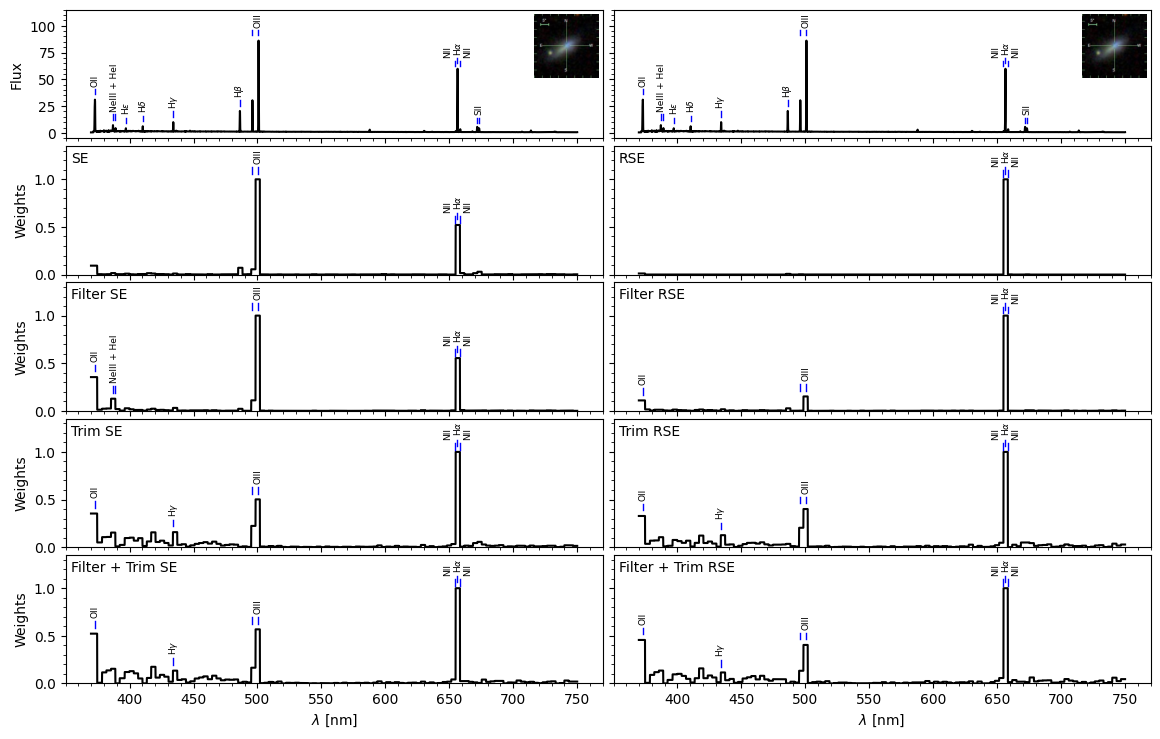

In [14]:
anomaly_name = "narrow_line"
data = all_explanations[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
spec_ylim = (-5, 115)
spec_yticks = range(0, 101, 25)
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [
            "OII",
            "NeIII",
            "H_epsilon",
            "H_delta",
            "H_gamma",
            "H_beta",
            "OIII",
            "H_alpha",
            "SII",
        ],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "OIII", "H_alpha"],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "OIII", "H_alpha"],
    },
    "RSE": {**base_exp_config, "active_lines": ["H_alpha"]},
    "Filter RSE": {**base_exp_config, "active_lines": ["OII", "OIII", "H_alpha"]},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "OIII", "H_alpha"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "OIII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# broad_line_large_OIII

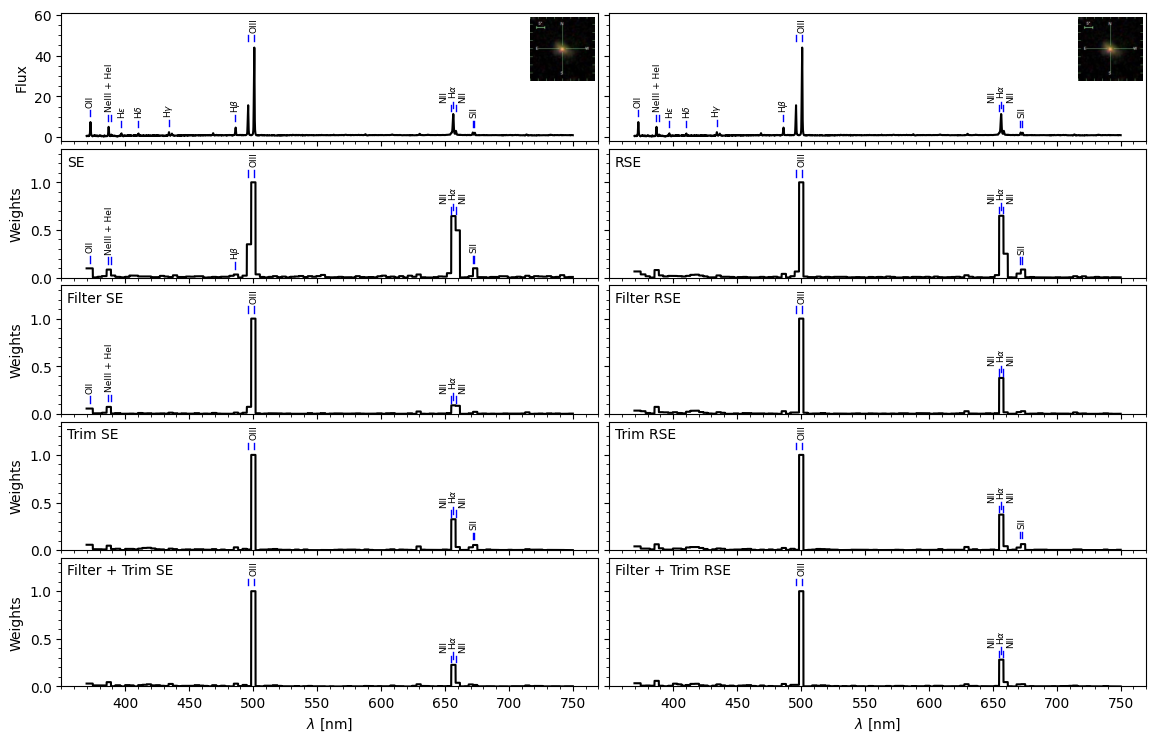

In [15]:
anomaly_name = "broad_line_large_OIII"
data = all_explanations[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

spec_ylim = (-2, 61)
spec_yticks = range(0, 61, 20)

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 3,
        "indicator_height": 3,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [
            "OII",
            "NeIII",
            "H_epsilon",
            "H_delta",
            "H_gamma",
            "H_beta",
            "OIII",
            "H_alpha",
            "SII",
        ],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha", "SII"],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": ["OIII", "H_alpha"]},
    "RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha", "SII"],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha"],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha", "SII"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# broad_emission_dips_OIII_half

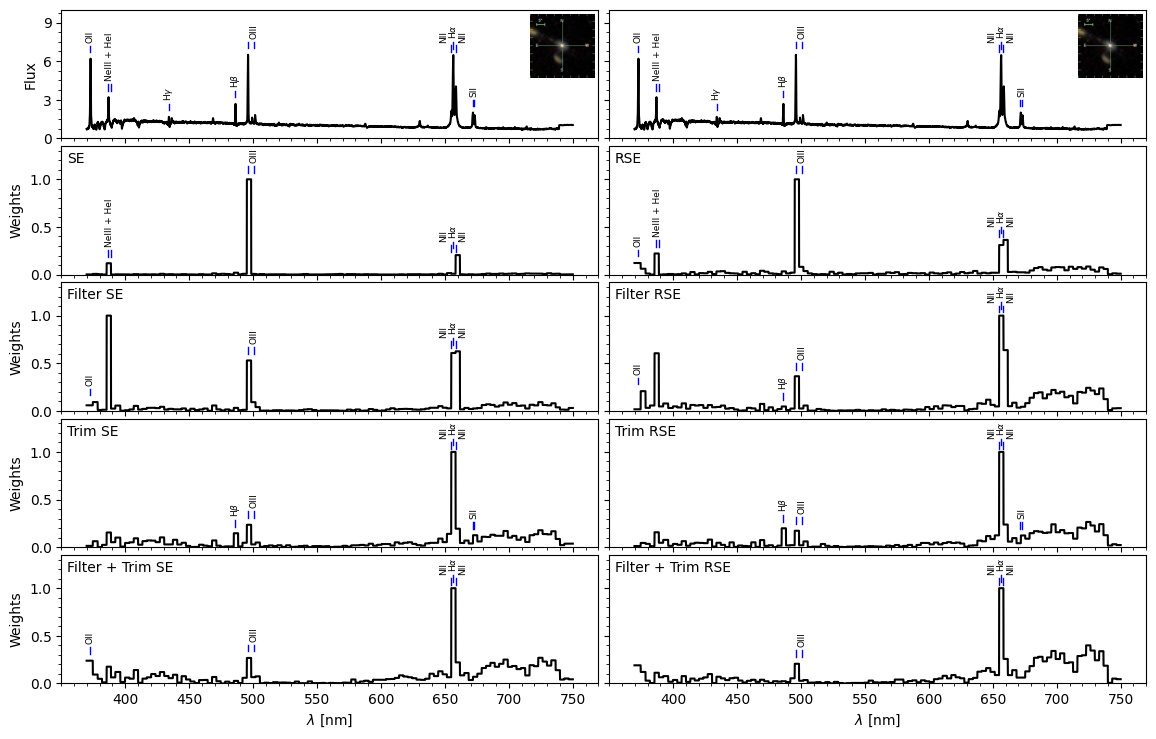

In [16]:
anomaly_name = "broad_emission_dips_OIII_half"
spec_ylim = (0, 10)
spec_yticks = range(0, 10, 3)
data = all_explanations[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

# Configuration for explanations
base_exp_config = {
    # "indicator_starts": 0.15,
    # "indicator_height": 0.15,
    "indicator_starts": 0.07,
    "indicator_height": 0.07,
    "delta": 5,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.5,
        "indicator_height": 0.5,
        "delta": 5,
        "fontsize": 6.5,
        "active_lines": [
            "OII",
            "NeIII",
            "H_gamma",
            "H_beta",
            "OIII",
            "H_alpha",
            "SII",
        ],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["NeIII", "OIII", "H_alpha"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OII", "OIII", "H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "OIII", "H_alpha"],
    },
    "RSE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_beta", "OIII", "H_alpha"],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)
plt.subplots_adjust(hspace=0.06, wspace=0.02)

# star_forming_step_blue_slope

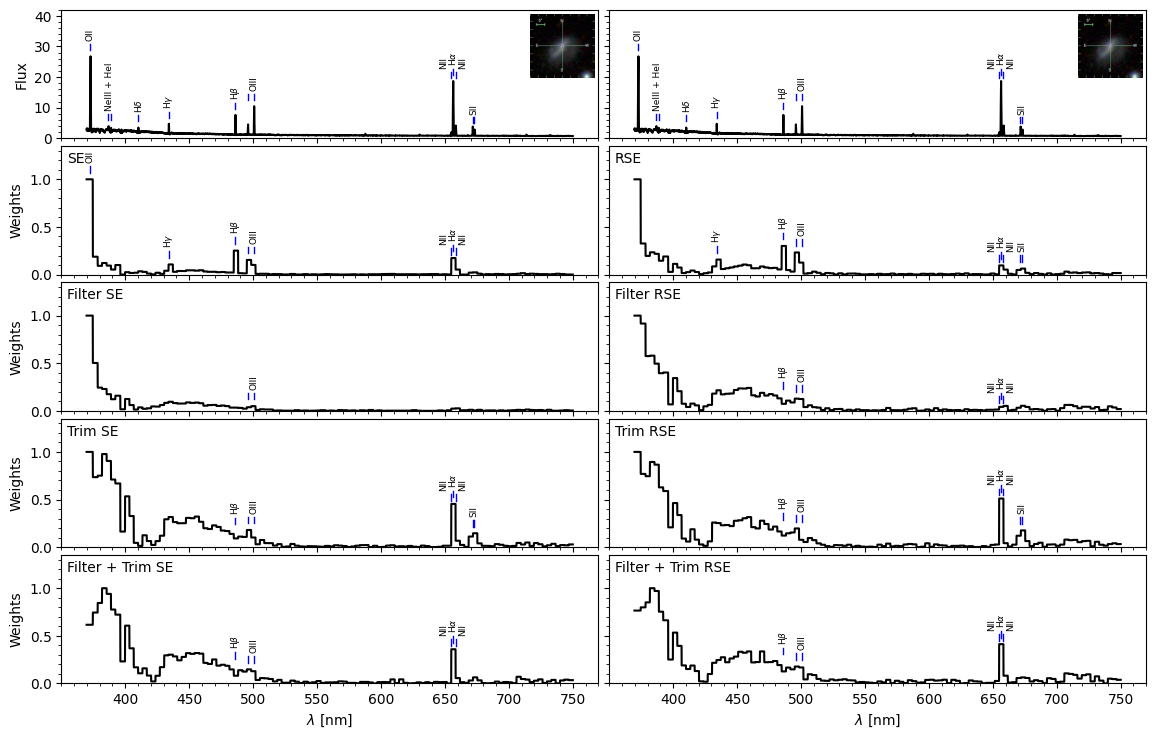

In [17]:
anomaly_name = "star_forming_step_blue_slope"
spec_ylim = (0, 42)
spec_yticks = range(0, 41, 10)
data = all_explanations[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.07,
    "indicator_height": 0.07,
    "delta": 5,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 2,
        "indicator_height": 2,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [
            "OII",
            "NeIII",
            "H_delta",
            "H_gamma",
            "H_beta",
            "OIII",
            "H_alpha",
            "SII",
        ],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "H_beta", "OIII", "H_alpha"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OIII"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha"],
    },
    "RSE": {
        **base_exp_config,
        "active_lines": ["H_gamma", "H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha"],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# blue_bump_emission

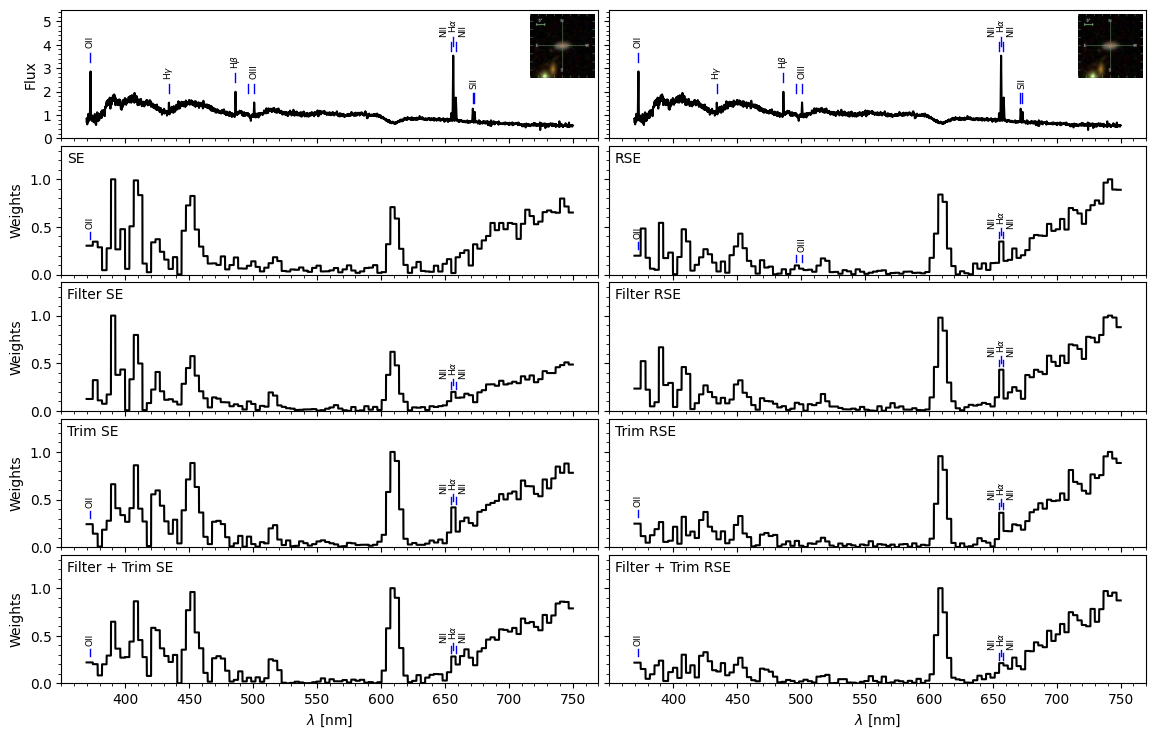

In [18]:
anomaly_name = "blue_bump_emission"

spec_ylim = (0, 5.5)
spec_yticks = range(0, 6, 1)

data = all_explanations[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.07,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.4,
        "indicator_height": 0.4,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": ["OII", "H_gamma", "H_beta", "OIII", "H_alpha", "SII"],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["OII"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "H_alpha"],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": ["OII", "H_alpha"]},
    "RSE": {
        **base_exp_config,
        "active_lines": ["OII", "OIII", "H_alpha"],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["H_alpha"],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_alpha"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# passive_star

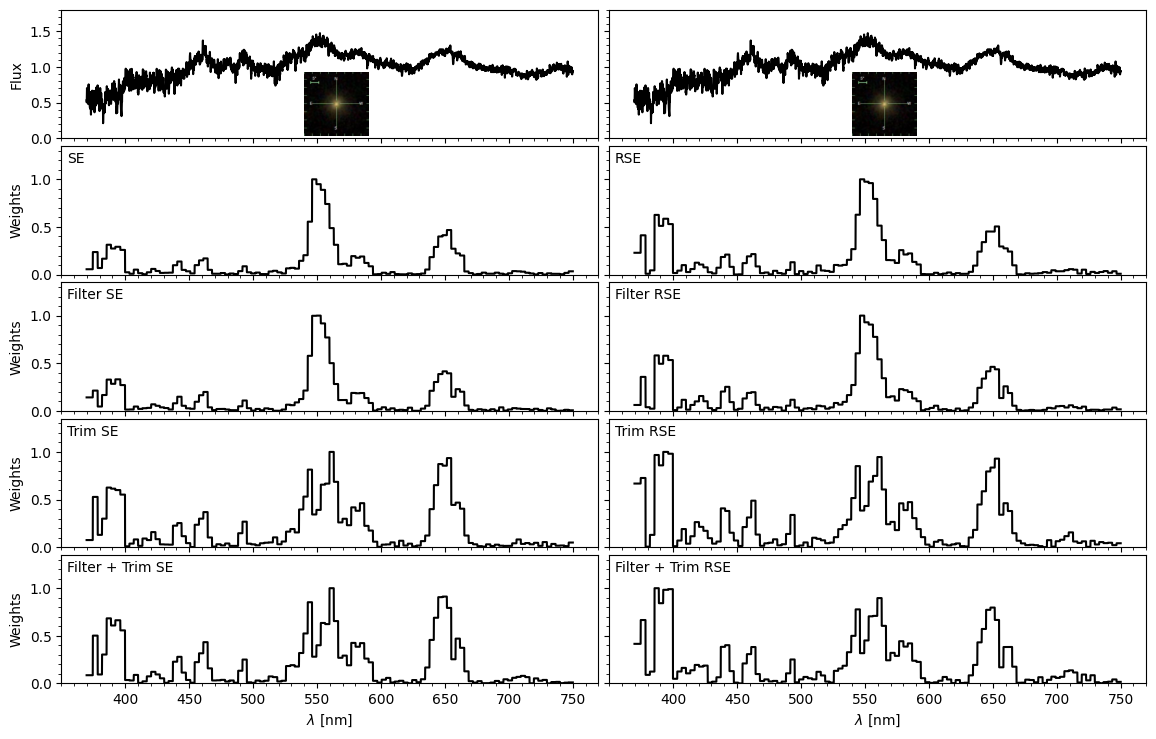

In [19]:
anomaly_name = "passive_star"
spec_ylim = (0, 1.8)
spec_yticks = [0, 0.5, 1, 1.5]

data = all_explanations[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.07,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.4,
        "indicator_height": 0.4,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": []},
    "RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
}
fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    bbox_to_anchor=(0.275, 0.07, 0.5, 0.5),
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# spike

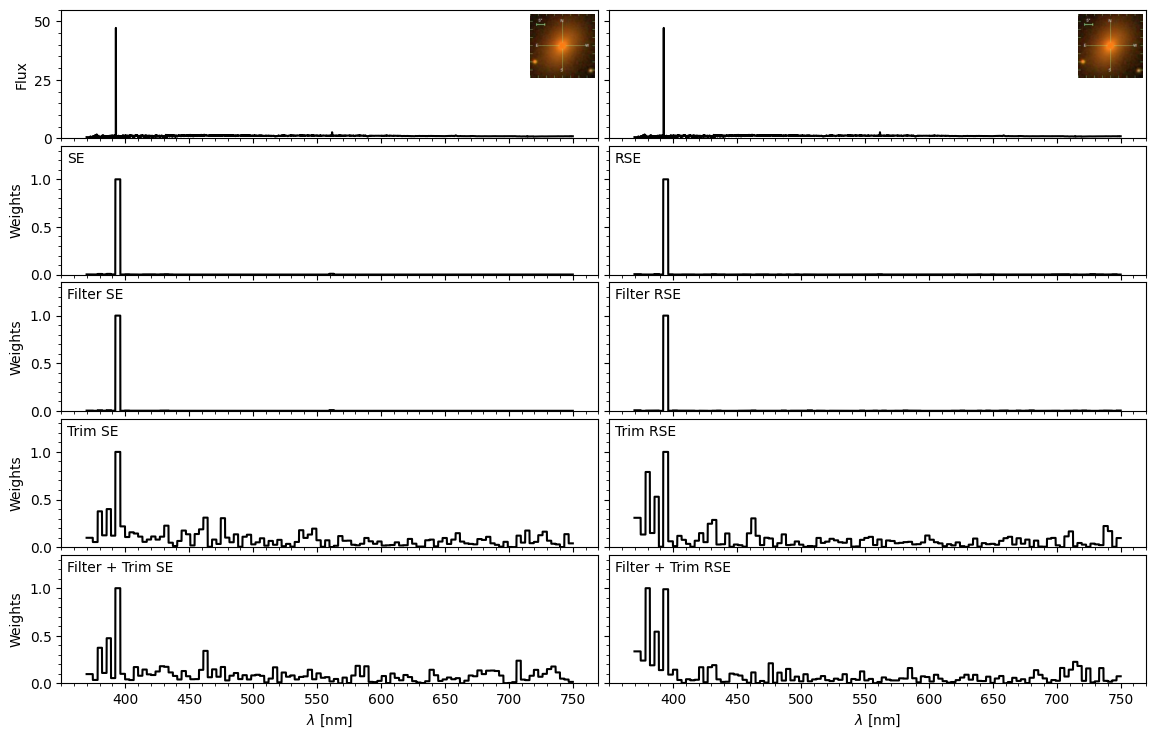

In [20]:
anomaly_name = "spike"

data = all_explanations[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

spec_ylim = (0, 55)
spec_yticks = range(0, 51, 25)

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.4,
        "indicator_height": 0.4,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": []},
    "RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
}
fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# noise_forest

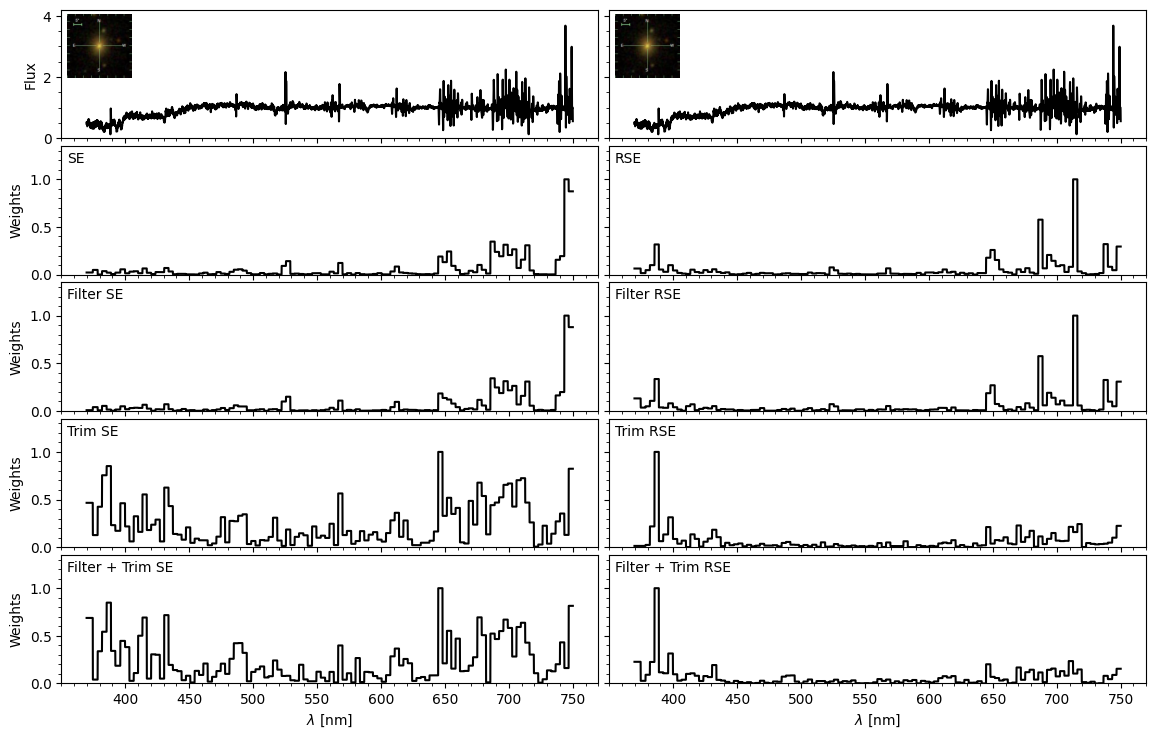

In [21]:
anomaly_name = "noise_forest"

data = all_explanations[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

spec_ylim = (0, 4.2)
spec_yticks = range(0, 5, 2)

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.4,
        "indicator_height": 0.4,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": []},
    "RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    bbox_to_anchor=(-0.167, 0.52, 0.5, 0.5),
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)